# Day 7 — Module 1: Comprehensive Statistical Measures & Outlier Treatment
**Programme:** C-DAC PGCP-AI | **Course:** Data Analytics
**Student / Author:** abs6187 (`23f2000876@ds.study.iitm.ac.in`)

### Core Objectives:
1. **Measures of Central Tendency:** Arithmetic Mean, Median, Mode, Geometric Mean, Harmonic Mean, Trimmed Mean, and **Winsorized Mean**.
2. **Measures of Dispersion & Position:** Range, Interquartile Range (IQR), Variance ($s^2$ vs $\sigma^2$), Standard Deviation ($s$), and Coefficient of Variation ($CV$).
3. **Outlier Detection & Handling:** Tukey's IQR Fences, Z-Scores, Trimming vs. Winsorization vs. Log Transformation.
4. **Visual Verification:** Dual-panel distribution and boxplot with annotated statistical milestones.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import mstats
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# ==============================================================================
# 1. SYNTHETIC DATASET: 200 EMPLOYEE SALARIES + 5 EXECUTIVE OUTLIERS
# ==============================================================================
# Base employees: Mean = $50,000, Std = $8,000
base_salaries = np.random.normal(loc=50000, scale=8000, size=200)
# Executive outliers: Severe right-skew
executive_salaries = np.array([140000, 160000, 180000, 220000, 250000])
salaries = np.concatenate([base_salaries, executive_salaries])
n = len(salaries)

print(f"Total Observations Generated : {n}")
print(f"Minimum Salary               : ${np.min(salaries):,.2f}")
print(f"Maximum Salary               : ${np.max(salaries):,.2f}")


Total Observations Generated : 205
Minimum Salary               : $29,042.04
Maximum Salary               : $250,000.00


### 1. Measures of Central Tendency
- **Arithmetic Mean:** Susceptible to extreme outliers.
- **Median:** Resilient 50th percentile.
- **Trimmed Mean:** Discards $\alpha\%$ from each tail (reduces sample size).
- **Winsorized Mean:** Caps extreme tails at $\alpha\%$ percentiles (preserves 100% sample size).
- **Geometric & Harmonic Means:** Specialized averages for multiplicative rates and ratios.


In [3]:
# 1. Arithmetic Mean & Median
mean_val = np.mean(salaries)
median_val = np.median(salaries)
mode_res = stats.mode(np.round(salaries, -3), keepdims=True)

# 2. Trimmed Mean (Trim 5% from each tail = 10% total)
trimmed_mean_05 = stats.trim_mean(salaries, proportiontocut=0.05)

# 3. Winsorized Mean (Cap 5% on each tail)
winsorized_arr = mstats.winsorize(salaries, limits=[0.05, 0.05])
winsorized_mean_05 = np.mean(winsorized_arr)

# 4. Geometric & Harmonic Mean (positive values only)
geo_mean = stats.gmean(salaries)
harm_mean = stats.hmean(salaries)

print("=" * 65)
print("           MEASURES OF CENTRAL TENDENCY COMPARISON            ")
print("=" * 65)
print(f"Arithmetic Mean           : ${mean_val:,.2f}  (Pulled up by CEO outliers)")
print(f"Median (50th Percentile)  : ${median_val:,.2f}  (Robust true center)")
print(f"Mode (Rounded $1k)        : ${mode_res.mode[0]:,.2f}  (Count: {mode_res.count[0]})")
print(f"5% Trimmed Mean           : ${trimmed_mean_05:,.2f}  (Tails dropped entirely)")
print(f"5% Winsorized Mean        : ${winsorized_mean_05:,.2f}  (Tails capped, N=205 kept)")
print(f"Geometric Mean            : ${geo_mean:,.2f}")
print(f"Harmonic Mean             : ${harm_mean:,.2f}")
print("=" * 65)


           MEASURES OF CENTRAL TENDENCY COMPARISON            
Arithmetic Mean           : $53,096.42  (Pulled up by CEO outliers)
Median (50th Percentile)  : $50,465.67  (Robust true center)
Mode (Rounded $1k)        : $52,000.00  (Count: 15)
5% Trimmed Mean           : $49,967.52  (Tails dropped entirely)
5% Winsorized Mean        : $50,121.81  (Tails capped, N=205 kept)
Geometric Mean            : $50,730.22
Harmonic Mean             : $49,417.65


### 2. Measures of Dispersion & Position
- **Range:** $Max - Min$ (sensitive to extrema).
- **IQR:** $Q_3 - Q_1$ (middle 50% spread, robust).
- **Variance ($s^2$):** Sample variance dividing by $n-1$ (Bessel's correction).
- **Coefficient of Variation ($CV$):** $\frac{s}{\bar{x}} \times 100\%$ (scale-free risk metric).


In [5]:
# Range and Quartiles
range_val = np.ptp(salaries)
q1, q2, q3 = np.percentile(salaries, [25, 50, 75])
iqr_val = q3 - q1

# Sample vs. Population Variance & Std
sample_var = np.var(salaries, ddof=1)
sample_std = np.std(salaries, ddof=1)
pop_std = np.std(salaries, ddof=0)
cv_val = (sample_std / mean_val) * 100

print("=" * 65)
print("           MEASURES OF DISPERSION & VARIABILITY              ")
print("=" * 65)
print(f"Range (Max - Min)         : ${range_val:,.2f}")
print(f"Quartile 1 (25th Pct)     : ${q1:,.2f}")
print(f"Quartile 2 (Median)       : ${q2:,.2f}")
print(f"Quartile 3 (75th Pct)     : ${q3:,.2f}")
print(f"Interquartile Range (IQR) : ${iqr_val:,.2f}")
print(f"Sample Variance (s²)      : {sample_var:,.2f} (ddof=1)")
print(f"Sample Std Dev (s)        : ${sample_std:,.2f}")
print(f"Population Std Dev (σ)    : ${pop_std:,.2f} (ddof=0)")
print(f"Coefficient of Variation  : {cv_val:.2f}%")
print("=" * 65)


           MEASURES OF DISPERSION & VARIABILITY              
Range (Max - Min)         : $220,957.96
Quartile 1 (25th Pct)     : $44,559.80
Quartile 2 (Median)       : $50,465.67
Quartile 3 (75th Pct)     : $54,694.86
Interquartile Range (IQR) : $10,135.05
Sample Variance (s²)      : 564,190,849.85 (ddof=1)
Sample Std Dev (s)        : $23,752.70
Population Std Dev (σ)    : $23,694.70 (ddof=0)
Coefficient of Variation  : 44.74%


### 3. Outlier Detection: Tukey's IQR Rule vs. Z-Score
- **IQR Fences:** $[Q_1 - 1.5\times IQR, \; Q_3 + 1.5\times IQR]$
- **Z-Score Cutoff:** $|Z| > 3.0$
- **Comparison:** Raw Mean vs. Trimmed vs. Winsorized


                  OUTLIER AUDIT REPORT                       
Tukey Lower Fence         : $29,357.22
Tukey Upper Fence         : $69,897.44
IQR Detected Outliers     : 7 points -> [ 29042.  71761. 140000. 160000. 180000. 220000. 250000.]
Z-Score Detected Outliers : 5 points (|Z| > 3.0)


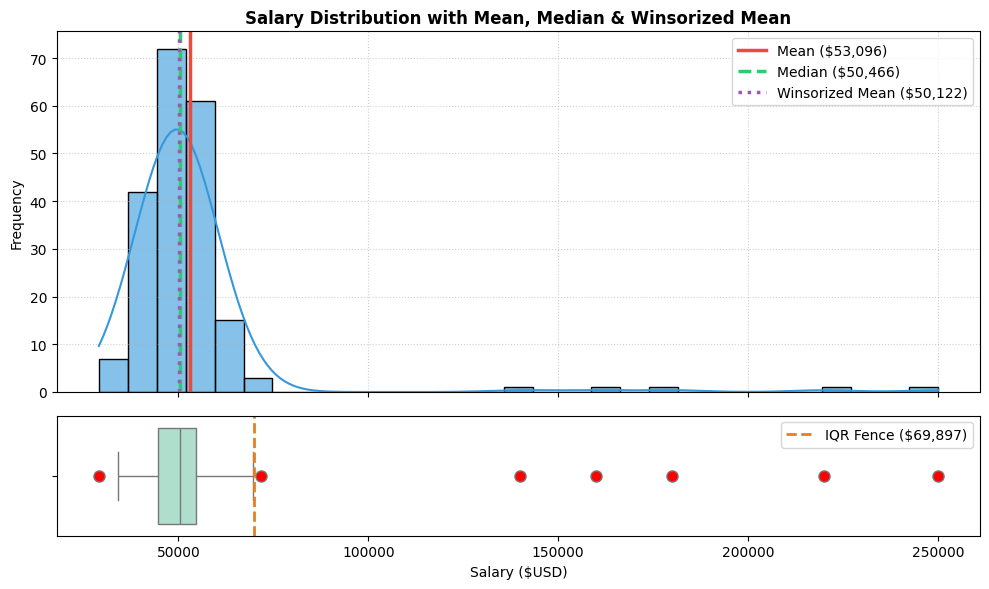

In [7]:
# Tukey's IQR Fences
lower_fence = q1 - 1.5 * iqr_val
upper_fence = q3 + 1.5 * iqr_val
iqr_outliers = salaries[(salaries < lower_fence) | (salaries > upper_fence)]

# Z-Score Detection
z_scores = (salaries - mean_val) / sample_std
z_outliers = salaries[np.abs(z_scores) > 3.0]

print("=" * 65)
print("                  OUTLIER AUDIT REPORT                       ")
print("=" * 65)
print(f"Tukey Lower Fence         : ${lower_fence:,.2f}")
print(f"Tukey Upper Fence         : ${upper_fence:,.2f}")
print(f"IQR Detected Outliers     : {len(iqr_outliers)} points -> {np.sort(np.round(iqr_outliers, 0))}")
print(f"Z-Score Detected Outliers : {len(z_outliers)} points (|Z| > 3.0)")
print("=" * 65)

# Graphical Visualization: Distribution + Boxplot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top: Histogram + KDE
sns.histplot(salaries, kde=True, ax=axes[0], color='#3498db', edgecolor='black', alpha=0.6)
axes[0].axvline(mean_val, color='#e74c3c', linestyle='-', linewidth=2.5, label=f'Mean (${mean_val:,.0f})')
axes[0].axvline(median_val, color='#2ecc71', linestyle='--', linewidth=2.5, label=f'Median (${median_val:,.0f})')
axes[0].axvline(winsorized_mean_05, color='#9b59b6', linestyle=':', linewidth=2.5, label=f'Winsorized Mean (${winsorized_mean_05:,.0f})')
axes[0].set_title('Salary Distribution with Mean, Median & Winsorized Mean', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Bottom: Boxplot showing outliers
sns.boxplot(x=salaries, ax=axes[1], color='#a8e6cf', flierprops={'marker':'o', 'markerfacecolor':'red', 'markersize':8})
axes[1].axvline(upper_fence, color='#e67e22', linestyle='--', linewidth=2, label=f'IQR Fence (${upper_fence:,.0f})')
axes[1].set_xlabel('Salary ($USD)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()
